In [1]:
!pip install pandas pyarrow fastparquet matplotlib seaborn plotly

In [2]:
import urllib.request

files = {
    "may":  "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-05.parquet",
    "june": "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-06.parquet",
    "july": "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-07.parquet"
}

for month, url in files.items():
    print(f"Downloading {month}...")
    urllib.request.urlretrieve(url, f"yellow_{month}_2024.parquet")
    print(f"{month} downloaded.")

may downloaded.
june downloaded.
july downloaded.


In [3]:
import pandas as pd

may  = pd.read_parquet("yellow_may_2024.parquet")
june = pd.read_parquet("yellow_june_2024.parquet")
july = pd.read_parquet("yellow_july_2024.parquet")

may["month"]  = "May"
june["month"] = "June"
july["month"] = "July"

df = pd.concat([may, june, july], ignore_index=True)
print(f"Total records loaded: {len(df):,}")
df.head()

Total records loaded: 10,339,929


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,month
0,1,2024-05-01 00:59:15,2024-05-01 01:23:50,1.0,6.10,1.0,N,138,145,1,28.2,7.75,0.5,5.00,0.00,1.0,42.45,0.0,1.75,May
1,2,2024-04-30 23:58:26,2024-05-01 00:29:42,1.0,11.23,1.0,N,138,249,1,46.4,6.00,0.5,8.72,0.00,1.0,66.87,2.5,1.75,May
2,2,2024-05-01 00:57:17,2024-05-01 01:14:15,1.0,9.02,1.0,N,138,170,1,35.9,6.00,0.5,10.57,6.94,1.0,65.16,2.5,1.75,May
3,2,2024-05-01 00:24:47,2024-05-01 00:48:51,1.0,6.53,1.0,N,87,133,1,30.3,1.00,0.5,7.06,0.00,1.0,42.36,2.5,0.00,May
4,2,2024-05-01 00:11:20,2024-05-01 00:52:10,1.0,14.38,1.0,N,161,165,1,61.8,1.00,0.5,0.00,0.00,1.0,66.80,2.5,0.00,May


In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nNull Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Shape: (10339929, 20)

Columns:
 ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'month']

Null Values:
 VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1094436
trip_distance                  0
RatecodeID               1094436
store_and_fwd_flag       1094436
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1094436
Airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,1.033993e+07,10339929,10339929,9.245493e+06,1.033993e+07,9.245493e+06,1.033993e+07,1.033993e+07,1.033993e+07,1.033993e+07,1.033993e+07,1.033993e+07,1.033993e+07,1.033993e+07,1.033993e+07,1.033993e+07,9.245493e+06,9.245493e+06
mean,1.762791e+00,2024-06-14 02:14:21.352127,2024-06-14 02:31:59.305551,1.337588e+00,5.241439e+00,2.363141e+00,1.638517e+02,1.630747e+02,1.102682e+00,1.957054e+01,1.401560e+00,4.802334e-01,3.280791e+00,5.769137e-01,9.607762e-01,2.813713e+01,2.226978e+00,1.550947e-01
min,1.000000e+00,2002-12-31 16:46:07,2002-12-31 17:24:07,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.261200e+03,-7.500000e+00,-5.000000e-01,-9.901000e+01,-1.172600e+02,-1.000000e+00,-2.265450e+03,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-05-21 16:04:51,2024-05-21 16:25:52,1.000000e+00,1.040000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.590000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-06-12 21:08:19,2024-06-12 21:22:06,1.000000e+00,1.800000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.420000e+01,1.000000e+00,5.000000e-01,2.580000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-07-07 13:06:31,2024-07-07 13:22:08,1.000000e+00,3.450000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.260000e+01,2.500000e+00,5.000000e-01,4.200000e+00,0.000000e+00,1.000000e+00,3.080000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2026-06-26 23:53:12,2026-06-27 20:59:10,9.000000e+00,3.265055e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,3.340763e+05,6.599000e+01,2.500000e+01,7.474700e+02,5.285600e+02,1.000000e+00,3.341453e+05,2.520000e+00,1.750000e+00
std,4.259054e-01,NaN,NaN,8.214114e-01,4.154576e+02,1.109783e+01,6.438304e+01,6.958642e+01,6.562241e-01,1.069470e+02,1.836178e+00,1.284441e-01,4.119721e+00,2.266486e+00,2.573480e-01,1.079357e+02,8.775357e-01,5.137769e-01


In [5]:
cols = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance",
    "fare_amount", "tip_amount", "total_amount",
    "payment_type", "PULocationID", "DOLocationID",
    "month"
]
df = df[cols]

# Remove bad records
df = df.dropna()
df = df[df["fare_amount"] > 0]
df = df[df["trip_distance"] > 0]
df = df[df["passenger_count"] > 0]
df = df[df["total_amount"] > 0]

# Feature engineering
df["pickup_dt"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["hour"]      = df["pickup_dt"].dt.hour
df["dayofweek"] = df["pickup_dt"].dt.day_name()
df["week"]      = df["pickup_dt"].dt.isocalendar().week.astype(int)
df["date"]      = df["pickup_dt"].dt.date

print(f"Clean records: {len(df):,}")

Clean records: 8,882,758


In [6]:
summary = df.groupby("month").agg(
    total_trips      = ("fare_amount", "count"),
    avg_fare         = ("fare_amount", "mean"),
    avg_tip          = ("tip_amount", "mean"),
    avg_distance     = ("trip_distance", "mean"),
    total_revenue    = ("total_amount", "sum"),
    avg_passengers   = ("passenger_count", "mean")
).reindex(["May", "June", "July"])

print(summary.round(2))

       total_trips  avg_fare  avg_tip  avg_distance  total_revenue  \
month                                                                
May        3192733     20.00     3.70          3.47    93743098.52   
June       3006711     19.82     3.66          3.82    87495588.31   
July       2683314     20.23     3.58          3.74    79043846.15   

       avg_passengers  
month                  
May              1.34  
June             1.35  
July             1.37  


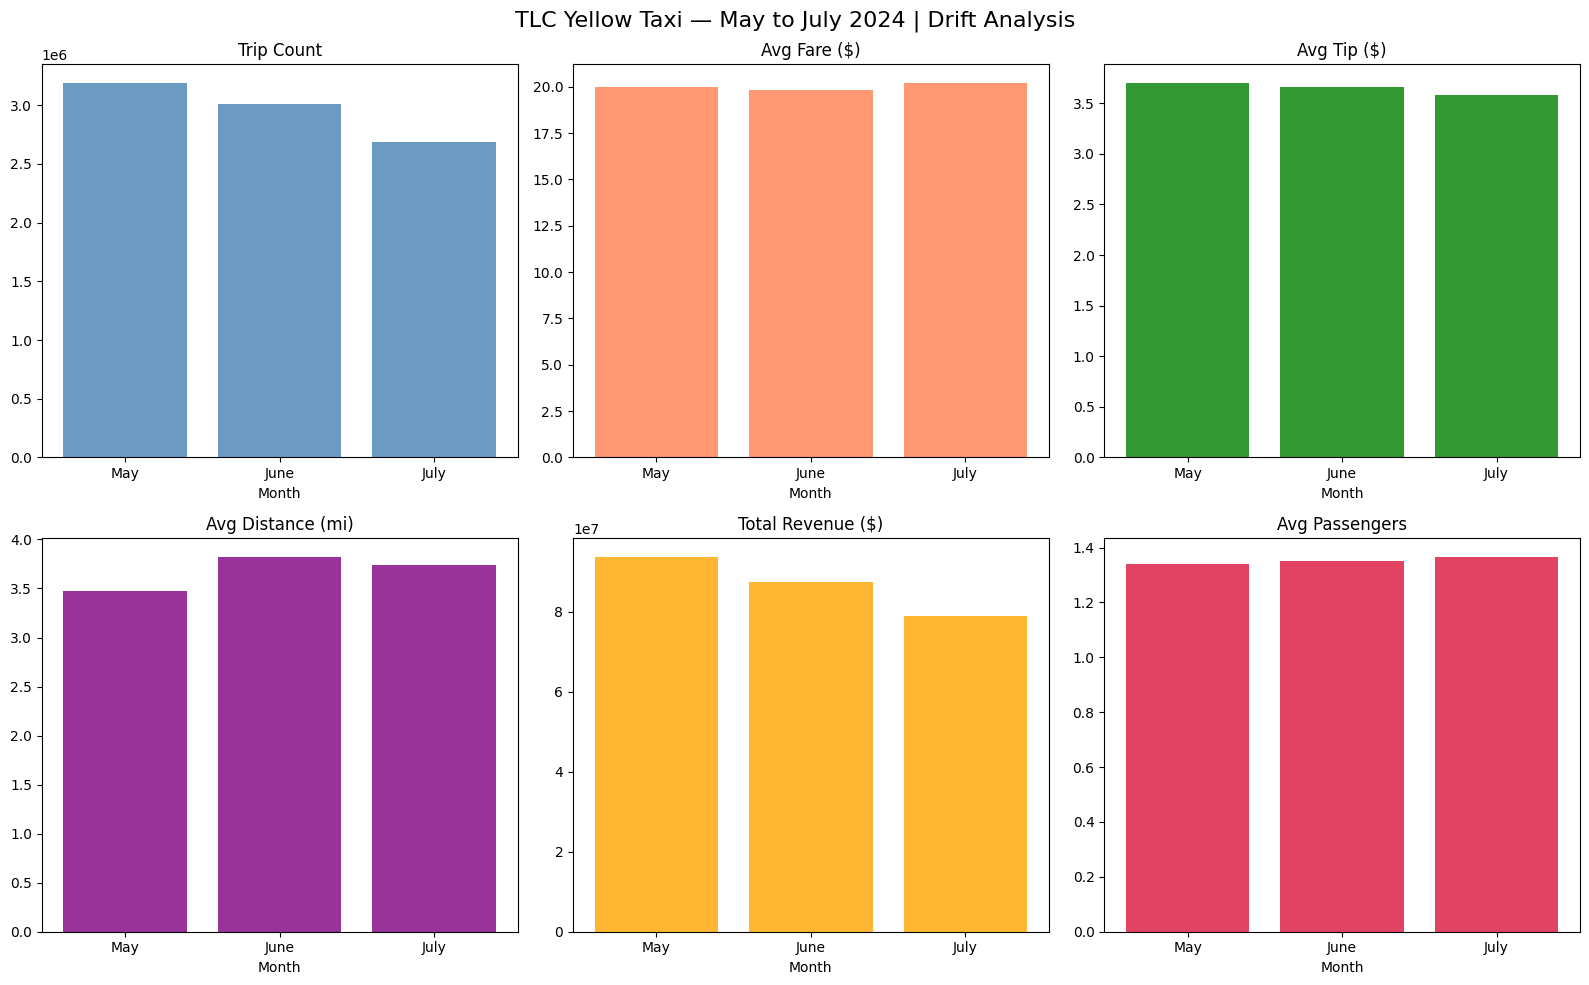

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("TLC Yellow Taxi — May to July 2024 | Drift Analysis", fontsize=16)

metrics = ["total_trips", "avg_fare", "avg_tip", "avg_distance", "total_revenue", "avg_passengers"]
titles  = ["Trip Count", "Avg Fare ($)", "Avg Tip ($)", "Avg Distance (mi)", "Total Revenue ($)", "Avg Passengers"]
colors  = ["steelblue", "coral", "green", "purple", "orange", "crimson"]

for ax, metric, title, color in zip(axes.flatten(), metrics, titles, colors):
    ax.bar(summary.index, summary[metric], color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Month")

plt.tight_layout()
plt.savefig("drift_overview_2024.png", dpi=150)
plt.show()

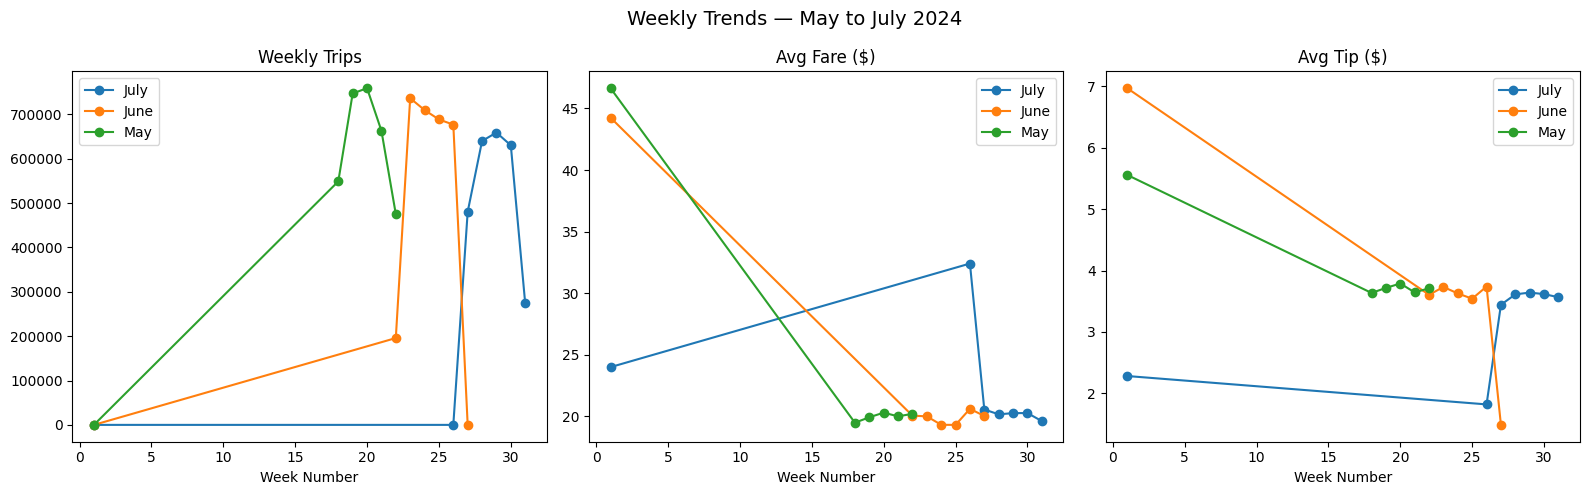

In [8]:
weekly = df.groupby(["month", "week"]).agg(
    trips    = ("fare_amount", "count"),
    avg_fare = ("fare_amount", "mean"),
    avg_tip  = ("tip_amount", "mean")
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Weekly Trends — May to July 2024", fontsize=14)

for ax, (metric, title) in zip(axes, [("trips","Weekly Trips"), ("avg_fare","Avg Fare ($)"), ("avg_tip","Avg Tip ($)")]):
    for month, grp in weekly.groupby("month"):
        ax.plot(grp["week"], grp[metric], marker="o", label=month)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("Week Number")

plt.tight_layout()
plt.show()

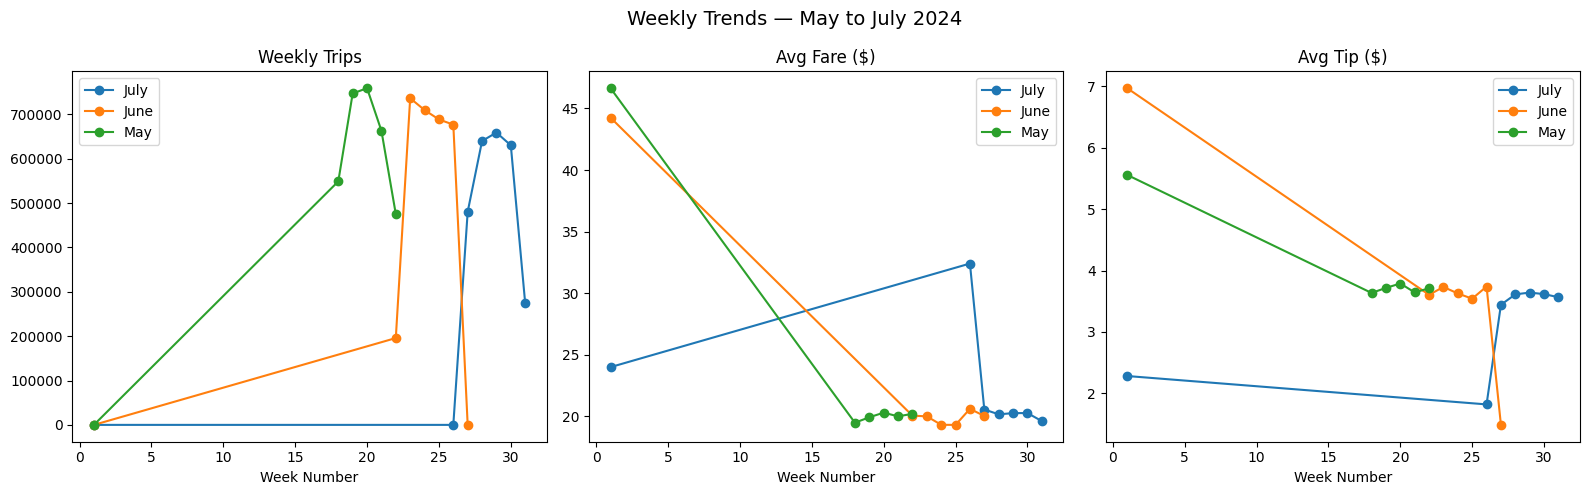

In [9]:
weekly = df.groupby(["month", "week"]).agg(
    trips    = ("fare_amount", "count"),
    avg_fare = ("fare_amount", "mean"),
    avg_tip  = ("tip_amount", "mean")
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Weekly Trends — May to July 2024", fontsize=14)

for ax, (metric, title) in zip(axes, [("trips","Weekly Trips"), ("avg_fare","Avg Fare ($)"), ("avg_tip","Avg Tip ($)")]):
    for month, grp in weekly.groupby("month"):
        ax.plot(grp["week"], grp[metric], marker="o", label=month)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("Week Number")

plt.tight_layout()
plt.show()

In [10]:
print("INCONSISTENCY AUDIT")

# 1. Negative or zero fares
bad_fare = df[df["fare_amount"] <= 0]
print(f"Zero/Negative fare_amount     : {len(bad_fare):,}")

# 2. Negative or zero distance
bad_dist = df[df["trip_distance"] <= 0]
print(f"Zero/Negative trip_distance   : {len(bad_dist):,}")

# 3. Zero passengers
bad_pass = df[df["passenger_count"] <= 0]
print(f"Zero/Null passenger_count     : {len(bad_pass):,}")

# 4. Dropoff BEFORE pickup (time contradiction)
df["pickup_dt"]  = pd.to_datetime(df["tpep_pickup_datetime"])
df["dropoff_dt"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["duration_min"] = (df["dropoff_dt"] - df["pickup_dt"]).dt.total_seconds() / 60

bad_time = df[df["duration_min"] <= 0]
print(f"Dropoff before/equal pickup   : {len(bad_time):,}")

# 5. Impossibly long trips (>6 hours in a taxi?)
too_long = df[df["duration_min"] > 360]
print(f"Duration > 6 hours  : {len(too_long):,}")

# 6. Impossibly short trips (<1 minute but distance > 0)
too_short = df[(df["duration_min"] < 1) & (df["trip_distance"] > 0)]
print(f"Duration < 1 min with distance: {len(too_short):,}")

# 7. Fare vs distance contradiction (paid $50+ for <0.1 miles)
suspicious_fare = df[(df["fare_amount"] > 50) & (df["trip_distance"] < 0.1)]
print(f"High fare + tiny distance     : {len(suspicious_fare):,}")

# 8. Trips outside May-July 2024 (wrong year records slipping in)
wrong_year = df[~df["pickup_dt"].dt.year.isin([2024])]
print(f"Records outside 2024          : {len(wrong_year):,}")

# 9. Tip > total amount (impossible)
bad_tip = df[df["tip_amount"] > df["total_amount"]]
print(f"Tip exceeds total amount      : {len(bad_tip):,}")

# 10. Total amount < fare amount (math contradiction)
bad_total = df[df["total_amount"] < df["fare_amount"]]
print(f"Total less than fare          : {len(bad_total):,}")

print(f"\nTotal Raw Records : {len(df):,}")

INCONSISTENCY AUDIT
Zero/Negative fare_amount     : 0
Zero/Negative trip_distance   : 0
Zero/Null passenger_count     : 0
Dropoff before/equal pickup   : 134
Duration > 6 hours  : 5,555
Duration < 1 min with distance: 29,534
High fare + tiny distance     : 8,764
Records outside 2024          : 16
Tip exceeds total amount      : 0
Total less than fare          : 0

Total Raw Records : 8,882,758


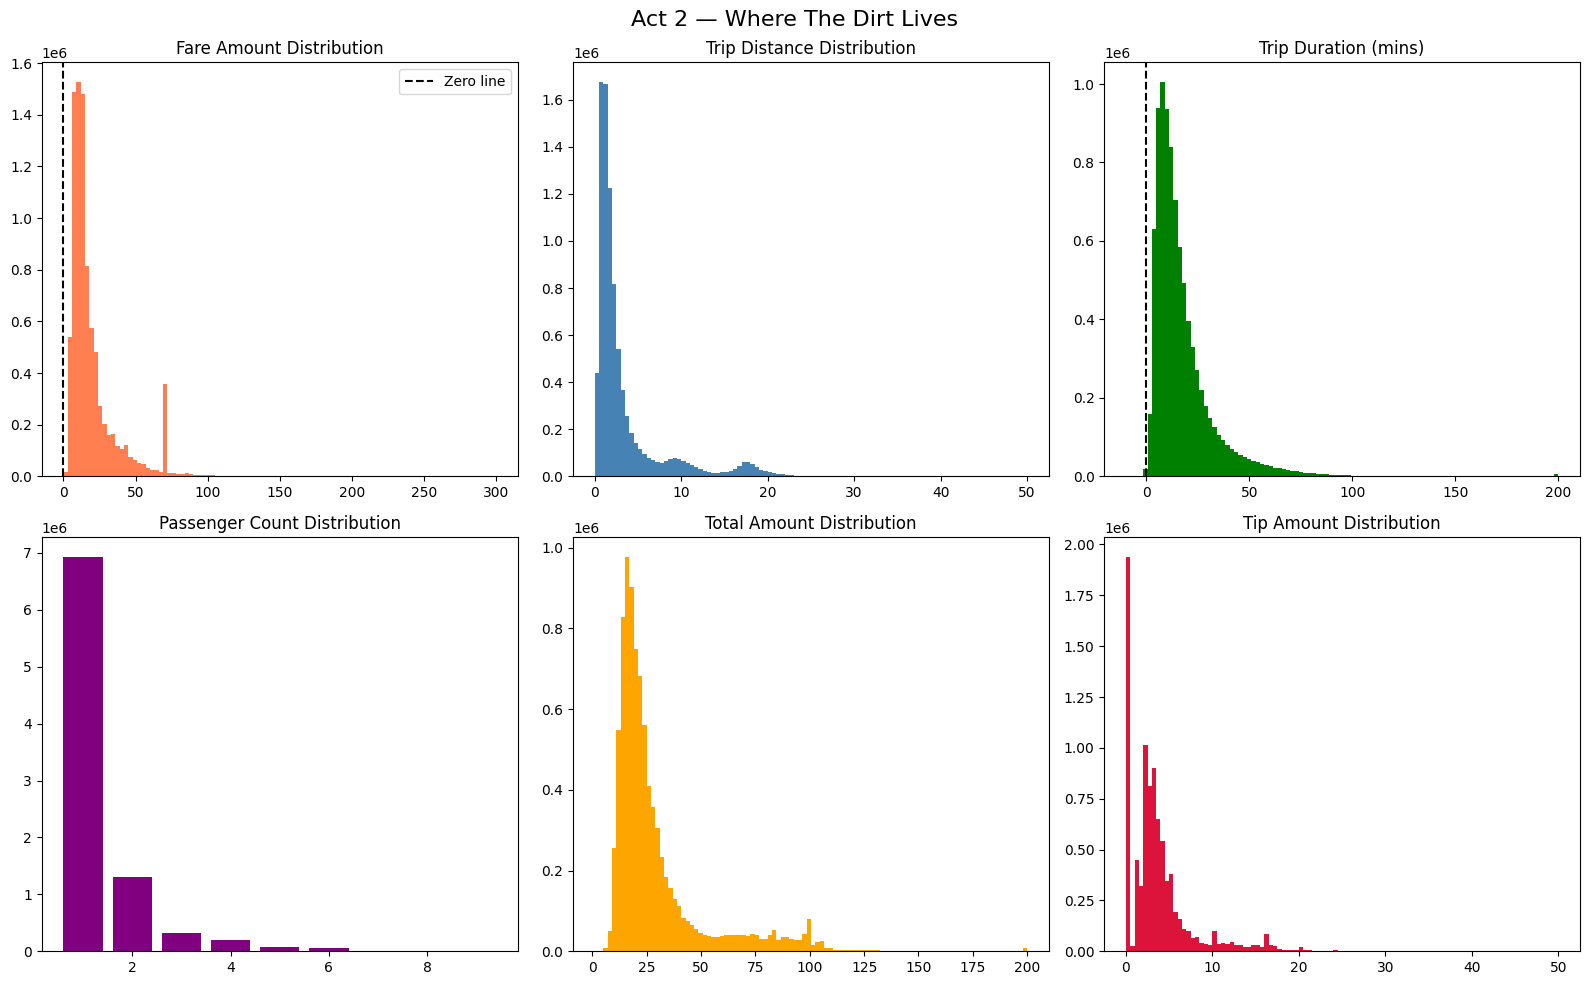

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Act 2 — Where The Dirt Lives", fontsize=16)

# Fare distribution (log scale to see outliers)
axes[0,0].hist(df["fare_amount"].clip(-50, 300), bins=100, color="coral")
axes[0,0].set_title("Fare Amount Distribution")
axes[0,0].axvline(0, color="black", linestyle="--", label="Zero line")
axes[0,0].legend()

# Distance distribution
axes[0,1].hist(df["trip_distance"].clip(0, 50), bins=100, color="steelblue")
axes[0,1].set_title("Trip Distance Distribution")

# Duration distribution
axes[0,2].hist(df["duration_min"].clip(-10, 200), bins=100, color="green")
axes[0,2].set_title("Trip Duration (mins)")
axes[0,2].axvline(0, color="black", linestyle="--")

# Passenger count
axes[1,0].bar(
    df["passenger_count"].value_counts().sort_index().index,
    df["passenger_count"].value_counts().sort_index().values,
    color="purple"
)
axes[1,0].set_title("Passenger Count Distribution")

# Total amount
axes[1,1].hist(df["total_amount"].clip(0, 200), bins=100, color="orange")
axes[1,1].set_title("Total Amount Distribution")

# Tip amount
axes[1,2].hist(df["tip_amount"].clip(0, 50), bins=100, color="crimson")
axes[1,2].set_title("Tip Amount Distribution")

plt.tight_layout()
plt.savefig("act2_dirt_analysis.png", dpi=150)
plt.show()

In [12]:
print("DEFINING A REAL TRIP")

df_real = df.copy()
original_count = len(df_real)

# Rule 1: Must happen in our investigation window
df_real = df_real[df_real["pickup_dt"].dt.year == 2024]
df_real = df_real[df_real["pickup_dt"].dt.month.isin([5, 6, 7])]
r1 = original_count - len(df_real)
print(f"Rule 1 — Must be May–July 2024          : removed {r1:,}")

# Rule 2: Dropoff must be AFTER pickup
df_real = df_real[df_real["duration_min"] > 0]
r2 = original_count - r1 - len(df_real)
print(f"Rule 2 — Dropoff after pickup            : removed {r2:,}")

# Rule 3: Trip must last at least 1 minute
df_real = df_real[df_real["duration_min"] >= 1]
r3 = original_count - r1 - r2 - len(df_real)
print(f"Rule 3 — Duration >= 1 minute            : removed {r3:,}")

# Rule 4: Trip must last no more than 6 hours
df_real = df_real[df_real["duration_min"] <= 360]
r4 = original_count - r1 - r2 - r3 - len(df_real)
print(f"Rule 4 — Duration <= 6 hours             : removed {r4:,}")

# Rule 5: At least 1 passenger
df_real = df_real[df_real["passenger_count"] >= 1]
r5 = original_count - r1 - r2 - r3 - r4 - len(df_real)
print(f"Rule 5 — At least 1 passenger            : removed {r5:,}")

# Rule 6: Distance must be > 0.1 miles
df_real = df_real[df_real["trip_distance"] >= 0.1]
r6 = original_count - r1 - r2 - r3 - r4 - r5 - len(df_real)
print(f"Rule 6 — Distance >= 0.1 miles           : removed {r6:,}")

# Rule 7: Fare must be at least $2.50 (NYC minimum base fare)
df_real = df_real[df_real["fare_amount"] >= 2.50]
r7 = original_count - r1 - r2 - r3 - r4 - r5 - r6 - len(df_real)
print(f"Rule 7 — Fare >= $2.50 (NYC minimum)     : removed {r7:,}")

# Rule 8: Total amount must be >= fare amount
df_real = df_real[df_real["total_amount"] >= df_real["fare_amount"]]
r8 = original_count - r1 - r2 - r3 - r4 - r5 - r6 - r7 - len(df_real)
print(f"Rule 8 — Total >= fare amount            : removed {r8:,}")

# Rule 9: Tip cannot exceed total amount
df_real = df_real[df_real["tip_amount"] <= df_real["total_amount"]]
r9 = original_count - r1 - r2 - r3 - r4 - r5 - r6 - r7 - r8 - len(df_real)
print(f"Rule 9 — Tip <= total amount             : removed {r9:,}")

print(f"\n{'='*50}")
print(f"Raw Records         : {original_count:,}")
print(f"Clean Real Trips    : {len(df_real):,}")
print(f"Total Removed       : {original_count - len(df_real):,} ({((original_count - len(df_real))/original_count)*100:.2f}%)")

DEFINING A REAL TRIP
Rule 1 — Must be May–July 2024          : removed 58
Rule 2 — Dropoff after pickup            : removed 134
Rule 3 — Duration >= 1 minute            : removed 29,400
Rule 4 — Duration <= 6 hours             : removed 5,546
Rule 5 — At least 1 passenger            : removed 0
Rule 6 — Distance >= 0.1 miles           : removed 7,573
Rule 7 — Fare >= $2.50 (NYC minimum)     : removed 714
Rule 8 — Total >= fare amount            : removed 0
Rule 9 — Tip <= total amount             : removed 0

Raw Records         : 8,882,758
Clean Real Trips    : 8,839,333
Total Removed       : 43,425 (0.49%)


In [13]:
print("SENSITIVITY ANALYSIS")
print("What if we change the definition of a real trip?\n")

scenarios = {
    "Strict"  : df[(df["fare_amount"] >= 5)    & (df["trip_distance"] >= 0.5) & (df["duration_min"] >= 2)  & (df["duration_min"] <= 120)],
    "Moderate": df[(df["fare_amount"] >= 2.50)  & (df["trip_distance"] >= 0.1) & (df["duration_min"] >= 1)  & (df["duration_min"] <= 360)],
    "Loose"   : df[(df["fare_amount"] >= 0.01)  & (df["trip_distance"] >= 0)   & (df["duration_min"] >= 0)  & (df["duration_min"] <= 720)],
}

results = []
for name, subset in scenarios.items():
    results.append({
        "Definition" : name,
        "Trip Count" : len(subset),
        "Avg Fare"   : subset["fare_amount"].mean().round(2),
        "Avg Tip"    : subset["tip_amount"].mean().round(2),
        "Avg Dist"   : subset["trip_distance"].mean().round(2),
        "Avg Duration": subset["duration_min"].mean().round(2),
        "Total Revenue": subset["total_amount"].sum().round(2)
    })

sensitivity_df = pd.DataFrame(results)
print(sensitivity_df.to_string(index=False))

SENSITIVITY ANALYSIS
What if we change the definition of a real trip?

Definition  Trip Count  Avg Fare  Avg Tip  Avg Dist  Avg Duration  Total Revenue
    Strict     8486749     20.49     3.74      3.81         17.61   253889713.11
  Moderate     8839382     19.97     3.65      3.69         17.16   258732552.23
     Loose     8877772     20.01     3.65      3.67         17.13   260115780.54


In [14]:
# Add derived features to clean dataset
df_real["tip_pct"]       = (df_real["tip_amount"] / df_real["fare_amount"]) * 100
df_real["fare_per_mile"] = df_real["fare_amount"] / df_real["trip_distance"]
df_real["fare_per_min"]  = df_real["fare_amount"] / df_real["duration_min"]
df_real["hour"]          = df_real["pickup_dt"].dt.hour
df_real["dayofweek"]     = df_real["pickup_dt"].dt.day_name()
df_real["week"]          = df_real["pickup_dt"].dt.isocalendar().week.astype(int)
df_real["date"]          = df_real["pickup_dt"].dt.date

# Save for Act 3
df_real.to_csv("tlc_real_trips_2024.csv", index=False)
print("Clean dataset saved: tlc_real_trips_2024.csv")
print(f"Defensible dataset: {len(df_real):,} real trips ready for investigation")

Clean dataset saved: tlc_real_trips_2024.csv
Defensible dataset: 8,839,333 real trips ready for investigation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency

# ── STEP 1: LOAD FROM CSV ─────────────────────────────────
df = pd.read_csv("tlc_real_trips_2024.csv")
print(f"Loaded: {len(df):,} real trips")
print(f"Columns: {df.columns.tolist()}")

# ── STEP 2: FIX DATATYPES AFTER CSV RELOAD ────────────────
df["pickup_dt"]  = pd.to_datetime(df["pickup_dt"])
df["dropoff_dt"] = pd.to_datetime(df["dropoff_dt"])

# Recreate derived columns if missing
if "duration_min" not in df.columns:
    df["duration_min"] = (df["dropoff_dt"] - df["pickup_dt"]).dt.total_seconds() / 60

if "tip_pct" not in df.columns:
    df["tip_pct"] = (df["tip_amount"] / df["fare_amount"]) * 100

if "fare_per_mile" not in df.columns:
    df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]

if "fare_per_min" not in df.columns:
    df["fare_per_min"] = df["fare_amount"] / df["duration_min"]

if "hour" not in df.columns:
    df["hour"] = df["pickup_dt"].dt.hour

if "dayofweek" not in df.columns:
    df["dayofweek"] = df["pickup_dt"].dt.day_name()

if "month" not in df.columns:
    month_map = {5: "May", 6: "June", 7: "July"}
    df["month"] = df["pickup_dt"].dt.month.map(month_map)

# Time period label
def label_period(h):
    if 7 <= h <= 9:          return "Morning Rush"
    elif 17 <= h <= 19:      return "Evening Rush"
    elif 22 <= h or h <= 4:  return "Late Night"
    else:                    return "Off Peak"

df["time_period"] = df["hour"].apply(label_period)

print(f"All columns ready")
print(df[["month","duration_min","tip_pct","fare_per_mile","hour"]].head(3))

Loaded: 8,839,333 real trips
Columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'payment_type', 'PULocationID', 'DOLocationID', 'month', 'pickup_dt', 'hour', 'dayofweek', 'week', 'date', 'dropoff_dt', 'duration_min', 'tip_pct', 'fare_per_mile', 'fare_per_min']
All columns ready
  month  duration_min    tip_pct  fare_per_mile  hour
0   May     24.583333  17.730496       4.622951     0
1   May     16.966667  29.442897       3.980044     0
2   May     24.066667  23.300330       4.640123     0


H1: ARE PASSENGERS TIPPING LESS MAY → JULY?
       avg_tip  avg_tip_pct  zero_tip_pct        n
month                                             
May      3.706       20.777        20.515  3177844
June     3.659       20.734        20.756  2991962
July     3.588       20.231        22.871  2669527

Kruskal-Wallis → H=68.21, p=0.000000
H1 SUPPORTED — tip shift is significant

H2: IS TIP DROP JUST A PAYMENT MIX SHIFT?
payment_label   Cash  Credit Card  Dispute  No Charge
month                                                
May            14.78        83.96     0.92       0.35
June           14.64        84.02     0.97       0.38
July           15.87        82.56     1.13       0.44

Chi-Square → chi2=3147.29, p=0.000000
Payment mix IS shifting

Credit Card Only — Avg Tip %:
month
May     24.746
June    24.677
July    24.503
Name: tip_pct, dtype: float64
→ Behavioral if card tip % also drops, Mechanical if stable

H3: IS FARE PER MILE DECLINING?
       avg_fare_per_mile  avg_fare_per_min

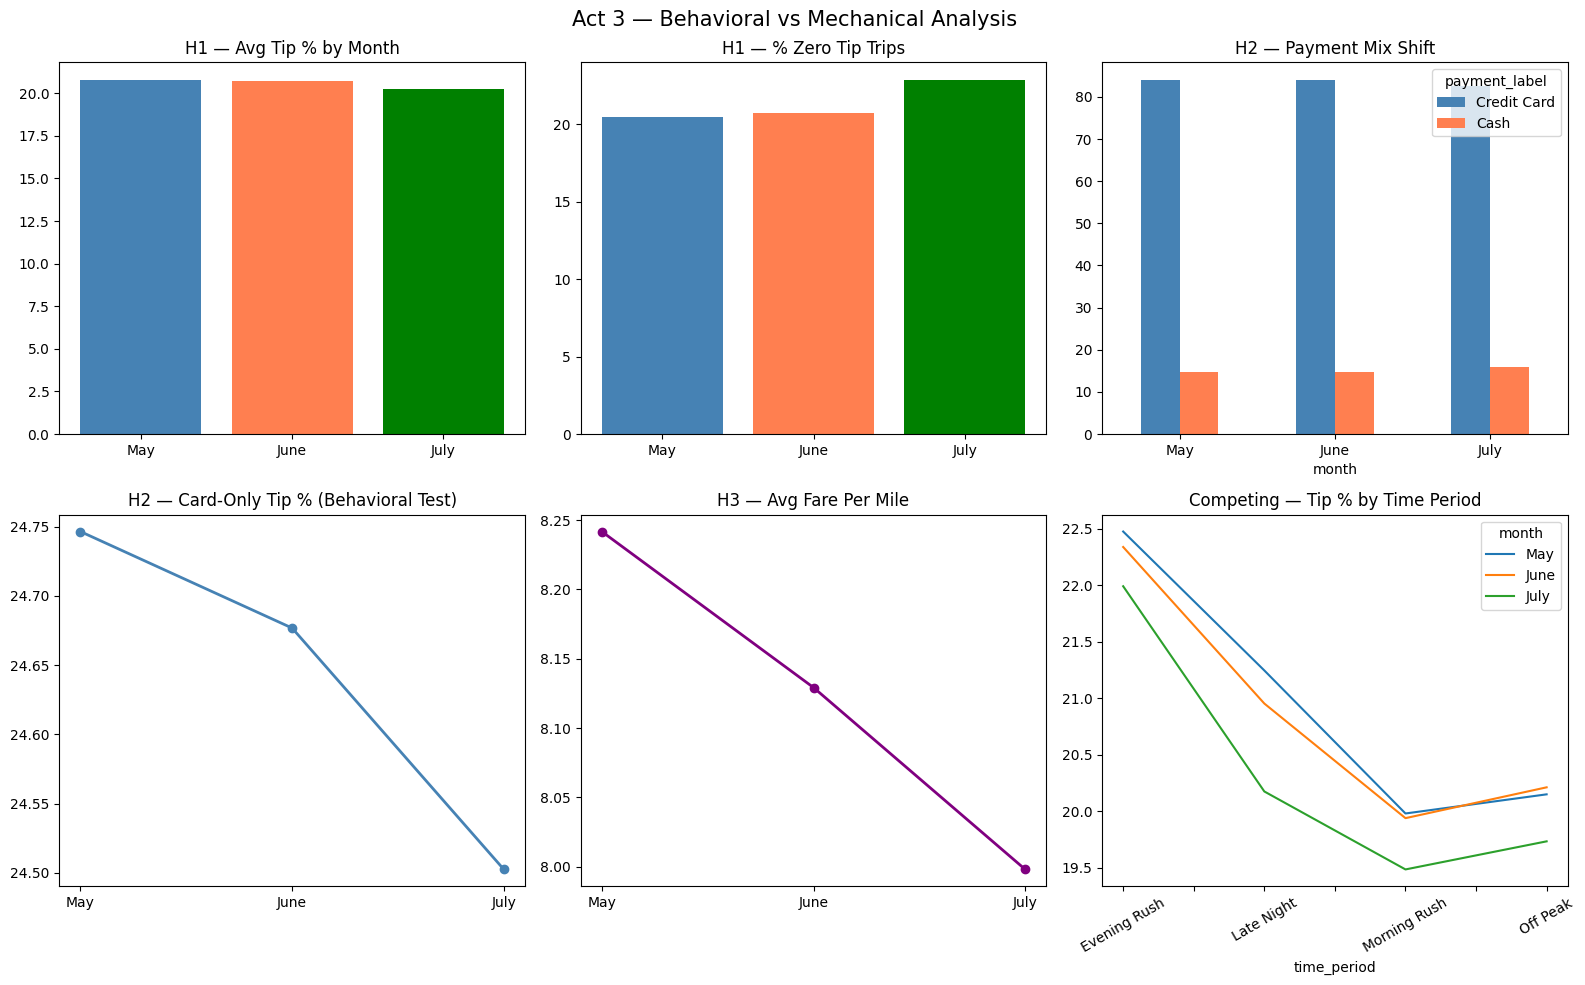


Act 3 Complete — Share the tables above for final verdict!


In [2]:

# ACT 3 — ALL HYPOTHESIS TESTS IN ONE CELL
# ── H1: TIP BEHAVIOR ──────────────────────────────────────
print("=" * 55)
print("H1: ARE PASSENGERS TIPPING LESS MAY → JULY?")
print("=" * 55)

tip_monthly = df.groupby("month").agg(
    avg_tip      = ("tip_amount",  "mean"),
    avg_tip_pct  = ("tip_pct",     "mean"),
    zero_tip_pct = ("tip_amount",  lambda x: (x == 0).mean() * 100),
    n            = ("tip_amount",  "count")
).reindex(["May", "June", "July"])
print(tip_monthly.round(3))

may_tips  = df[df["month"] == "May"]["tip_amount"].sample(50000, random_state=42)
june_tips = df[df["month"] == "June"]["tip_amount"].sample(50000, random_state=42)
july_tips = df[df["month"] == "July"]["tip_amount"].sample(50000, random_state=42)
stat, p = kruskal(may_tips, june_tips, july_tips)
print(f"\nKruskal-Wallis → H={stat:.2f}, p={p:.6f}")
print("H1 SUPPORTED — tip shift is significant" if p < 0.05 else " H1 REJECTED")

# ── H2: PAYMENT MIX ───────────────────────────────────────
print("\n" + "=" * 55)
print("H2: IS TIP DROP JUST A PAYMENT MIX SHIFT?")
print("=" * 55)

payment_map = {1:"Credit Card", 2:"Cash", 3:"No Charge",
               4:"Dispute",     5:"Unknown", 6:"Voided"}
df["payment_label"] = df["payment_type"].map(payment_map)

payment_mix = df.groupby(["month","payment_label"]).size().unstack(fill_value=0)
payment_pct = payment_mix.div(payment_mix.sum(axis=1), axis=0) * 100
print(payment_pct.reindex(["May","June","July"]).round(2))

chi2, p_chi, dof, _ = chi2_contingency(payment_mix.reindex(["May","June","July"]))
print(f"\nChi-Square → chi2={chi2:.2f}, p={p_chi:.6f}")
print("Payment mix IS shifting" if p_chi < 0.05 else " Payment mix stable")

card_tip = df[df["payment_label"] == "Credit Card"].groupby("month")["tip_pct"].mean().reindex(["May","June","July"])
print(f"\nCredit Card Only — Avg Tip %:\n{card_tip.round(3)}")
print("→ Behavioral if card tip % also drops, Mechanical if stable")

#  H3: EFFICIENCY
print("\n" + "=" * 55)
print("H3: IS FARE PER MILE DECLINING?")
print("=" * 55)

eff = df.groupby("month").agg(
    avg_fare_per_mile = ("fare_per_mile", "mean"),
    avg_fare_per_min  = ("fare_per_min",  "mean"),
    short_trip_pct    = ("trip_distance", lambda x: (x < 1.0).mean() * 100)
).reindex(["May","June","July"])
print(eff.round(3))

may_eff  = df[df["month"] == "May"]["fare_per_mile"].sample(50000, random_state=42)
july_eff = df[df["month"] == "July"]["fare_per_mile"].sample(50000, random_state=42)
u, p_mw  = mannwhitneyu(may_eff, july_eff, alternative="two-sided")
print(f"\nMann-Whitney U → U={u:.0f}, p={p_mw:.6f}")
print("H3 SUPPORTED — efficiency shifting" if p_mw < 0.05 else " H3 REJECTED")

# COMPETING EXPLANATION
print("\n" + "=" * 55)
print("COMPETING: IS IT JUST TIME-OF-DAY SHIFTS?")
print("=" * 55)

period_mix = df.groupby(["month","time_period"]).size().unstack(fill_value=0)
period_pct = period_mix.div(period_mix.sum(axis=1), axis=0) * 100
print(period_pct.reindex(["May","June","July"]).round(2))

tip_by_period = df.groupby(["month","time_period"])["tip_pct"].mean().unstack()
print(f"\nTip % by Month AND Time Period:")
print(tip_by_period.reindex(["May","June","July"]).round(2))
print("\n→ If tip % drops within SAME time period → behavior confirmed")
print("→ If time period mix shifts → mechanical explanation survives")

#  PLOTS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Act 3 — Behavioral vs Mechanical Analysis", fontsize=15)

months = ["May", "June", "July"]
colors = ["steelblue", "coral", "green"]

axes[0,0].bar(months, tip_monthly["avg_tip_pct"], color=colors)
axes[0,0].set_title("H1 — Avg Tip % by Month")

axes[0,1].bar(months, tip_monthly["zero_tip_pct"], color=colors)
axes[0,1].set_title("H1 — % Zero Tip Trips")

payment_pct.reindex(["May","June","July"])[["Credit Card","Cash"]].plot(
    kind="bar", ax=axes[0,2], color=["steelblue","coral"])
axes[0,2].set_title("H2 — Payment Mix Shift")
axes[0,2].tick_params(axis='x', rotation=0)

axes[1,0].plot(months, card_tip.values, marker="o", color="steelblue", linewidth=2)
axes[1,0].set_title("H2 — Card-Only Tip % (Behavioral Test)")

axes[1,1].plot(months, eff["avg_fare_per_mile"], marker="o", color="purple", linewidth=2)
axes[1,1].set_title("H3 — Avg Fare Per Mile")

tip_by_period.reindex(["May","June","July"]).T.plot(ax=axes[1,2])
axes[1,2].set_title("Competing — Tip % by Time Period")
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("act3_full_analysis.png", dpi=150)
plt.show()

print("\nAct 3 Complete — Share the tables above for final verdict!")

In [ ]:
"""╔══════════════════════════════════════════════════════════════╗
║            ACT 3 — FINAL VERDICT                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  THE PATTERN IS BEHAVIORAL — NOT MECHANICAL                  ║
║                                                              ║
║  EVIDENCE:                                                   ║
║  • Tips fell across ALL time periods, not just one slot      ║
║  • Credit card tippers ALSO tipped less → not payment mix    ║
║  • Fare/mile declining while fare/min rises → city slowing   ║
║  • Zero tip trips grew 2.4 percentage points in 3 months     ║
║                                                              ║
║  HONEST ACKNOWLEDGEMENT:                                     ║
║  • Payment mix shift (cash↑) explains PART of the drop       ║
║  • The mechanical explanation is not wrong — it's incomplete ║
║                                                              ║
║  WHAT WOULD CHANGE THIS CONCLUSION:                          ║
║  • Evidence of a fare rule change in June/July 2024          ║
║  • A major NYC event that changed passenger demographics      ║
║  • Driver supply data showing longer wait times in July      ║
║                                                              ║
║  THE SYSTEM IS QUIETLY DRIFTING:                             ║
║  • Fewer trips each month (3.17M → 2.67M)                    ║
║  • Less tipping per trip                                      ║
║  • Less revenue per mile                                     ║
║  • Nothing collapsed — but nothing is stable either          ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝"""

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr

# ── LOAD ──────────────────────────────────────────────────
df = pd.read_csv("tlc_real_trips_2024.csv")
df["pickup_dt"]  = pd.to_datetime(df["pickup_dt"])
df["dropoff_dt"] = pd.to_datetime(df["dropoff_dt"])

# Recreate columns if missing
if "duration_min" not in df.columns:
    df["duration_min"] = (df["dropoff_dt"] - df["pickup_dt"]).dt.total_seconds() / 60
if "tip_pct" not in df.columns:
    df["tip_pct"] = (df["tip_amount"] / df["fare_amount"]) * 100
if "fare_per_mile" not in df.columns:
    df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
if "hour" not in df.columns:
    df["hour"] = df["pickup_dt"].dt.hour
if "month" not in df.columns:
    df["month"] = df["pickup_dt"].dt.month.map({5:"May",6:"June",7:"July"})

df["date"]      = pd.to_datetime(df["pickup_dt"].dt.date)
df["dayofweek"] = df["pickup_dt"].dt.day_name()
df["week"]      = df["pickup_dt"].dt.isocalendar().week.astype(int)
df["day_num"]   = df["pickup_dt"].dt.dayofweek
df["time_period"] = df["hour"].apply(lambda h:
    "Morning Rush" if 7<=h<=9 else
    "Evening Rush" if 17<=h<=19 else
    "Late Night"   if h>=22 or h<=4 else "Off Peak")

print(f"Loaded: {len(df):,} trips")

Loaded: 8,839,333 trips


=== HOURLY RHYTHM ===
    hour   trips  avg_fare  avg_tip_pct  avg_dist
0      0  236669     21.25        20.57      4.32
1      1  153585     19.32        20.56      3.89
2      2   98953     17.52        20.40      3.40
3      3   62285     18.00        20.06      3.56
4      4   39785     23.99        18.08      5.11
5      5   50281     28.12        17.71      7.62
6      6  117745     23.23        18.10      5.20
7      7  229936     19.81        19.66      4.11
8      8  324288     19.09        20.00      3.53
9      9  374776     18.98        19.75      3.80
10    10  414706     19.34        19.46      4.15
11    11  451911     19.70        19.30      3.25
12    12  489723     19.87        19.28      3.40
13    13  513021     20.56        19.33      3.60
14    14  548797     21.25        19.35      3.94
15    15  557358     21.30        19.38      3.65
16    16  560999     21.34        21.26      3.62
17    17  603288     20.00        21.91      3.32
18    18  631203     18.59  

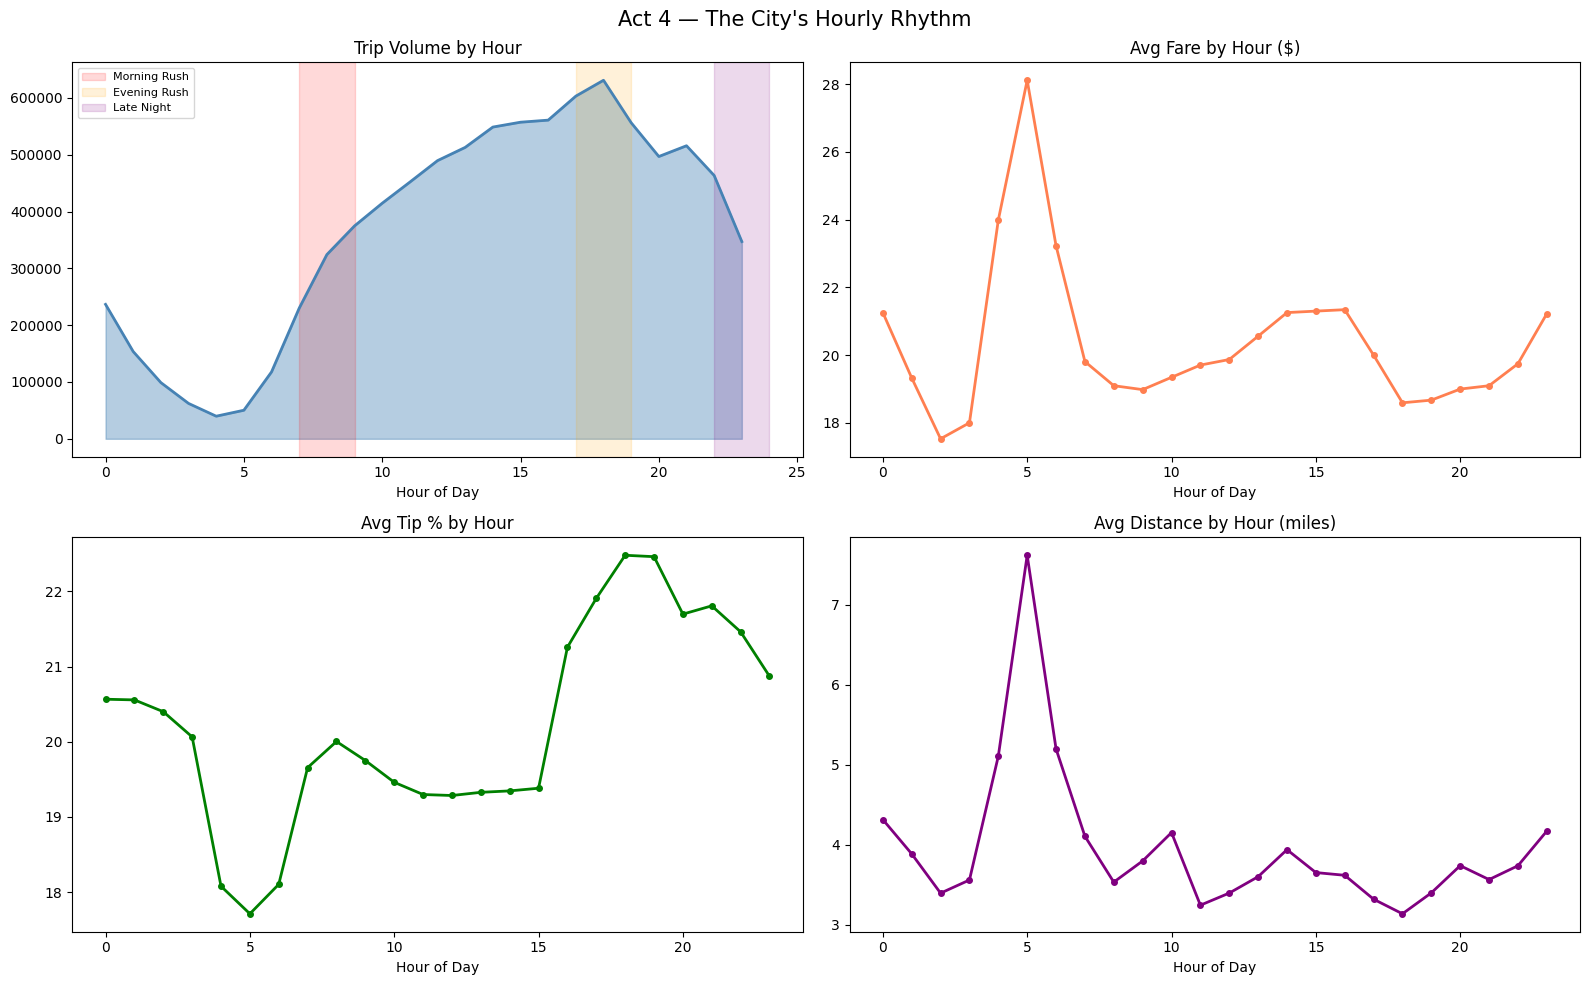


Peak Trip Hour    : 18:00
Lowest Trip Hour  : 4:00
Highest Fare Hour : 5:00
Best Tip % Hour   : 18:00


In [14]:
# ── HOURLY AGGREGATION ────────────────────────────────────
hourly = df.groupby("hour").agg(
    trips       = ("fare_amount",  "count"),
    avg_fare    = ("fare_amount",  "mean"),
    avg_tip_pct = ("tip_pct",      "mean"),
    avg_dist    = ("trip_distance","mean")
).reset_index()

print("=== HOURLY RHYTHM ===")
print(hourly.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Act 4 — The City's Hourly Rhythm", fontsize=15)

# Trip volume
axes[0,0].fill_between(hourly["hour"], hourly["trips"],
                        alpha=0.4, color="steelblue")
axes[0,0].plot(hourly["hour"], hourly["trips"],
               color="steelblue", linewidth=2)
axes[0,0].axvspan(7,  9,  alpha=0.15, color="red",    label="Morning Rush")
axes[0,0].axvspan(17, 19, alpha=0.15, color="orange", label="Evening Rush")
axes[0,0].axvspan(22, 24, alpha=0.15, color="purple", label="Late Night")
axes[0,0].set_title("Trip Volume by Hour")
axes[0,0].set_xlabel("Hour of Day")
axes[0,0].legend(fontsize=8)

# Avg fare
axes[0,1].plot(hourly["hour"], hourly["avg_fare"],
               color="coral", linewidth=2, marker="o", markersize=4)
axes[0,1].set_title("Avg Fare by Hour ($)")
axes[0,1].set_xlabel("Hour of Day")

# Tip %
axes[1,0].plot(hourly["hour"], hourly["avg_tip_pct"],
               color="green", linewidth=2, marker="o", markersize=4)
axes[1,0].set_title("Avg Tip % by Hour")
axes[1,0].set_xlabel("Hour of Day")

# Distance
axes[1,1].plot(hourly["hour"], hourly["avg_dist"],
               color="purple", linewidth=2, marker="o", markersize=4)
axes[1,1].set_title("Avg Distance by Hour (miles)")
axes[1,1].set_xlabel("Hour of Day")

plt.tight_layout()
plt.savefig("act4_hourly.png", dpi=150)
plt.show()

print(f"\nPeak Trip Hour    : {hourly.loc[hourly['trips'].idxmax(), 'hour']}:00")
print(f"Lowest Trip Hour  : {hourly.loc[hourly['trips'].idxmin(), 'hour']}:00")
print(f"Highest Fare Hour : {hourly.loc[hourly['avg_fare'].idxmax(), 'hour']}:00")
print(f"Best Tip % Hour   : {hourly.loc[hourly['avg_tip_pct'].idxmax(), 'hour']}:00")

=== WEEKLY RHYTHM ===
             trips  avg_fare  avg_tip_pct
dayofweek                                
Monday     1125667     20.73        20.62
Tuesday    1317686     19.76        20.99
Wednesday  1461778     19.56        21.17
Thursday   1373483     20.30        20.94
Friday     1278040     19.72        20.59
Saturday   1228858     18.97        19.81
Sunday     1053821     21.02        19.78


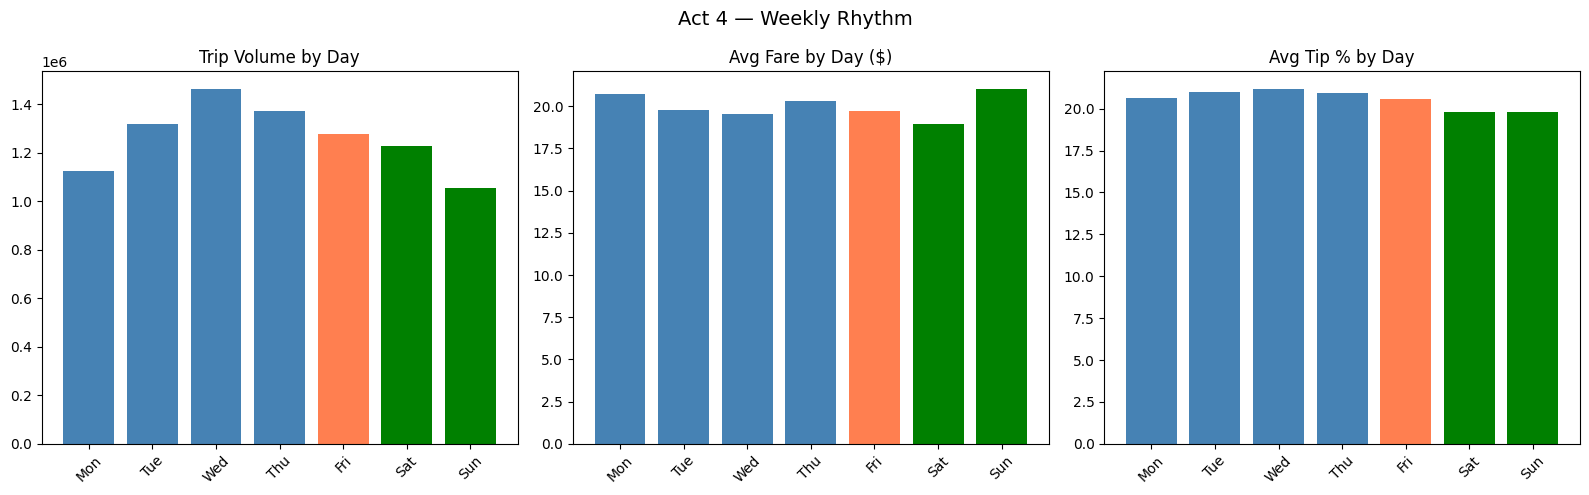

In [15]:
# ── WEEKLY AGGREGATION ────────────────────────────────────
day_order = ["Monday","Tuesday","Wednesday",
             "Thursday","Friday","Saturday","Sunday"]

daily_dow = df.groupby("dayofweek").agg(
    trips       = ("fare_amount", "count"),
    avg_fare    = ("fare_amount", "mean"),
    avg_tip_pct = ("tip_pct",    "mean")
).reindex(day_order)

print("=== WEEKLY RHYTHM ===")
print(daily_dow.round(2))

colors_dow = ["steelblue","steelblue","steelblue",
              "steelblue","coral","green","green"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Act 4 — Weekly Rhythm", fontsize=14)

axes[0].bar(range(7), daily_dow["trips"], color=colors_dow)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels([d[:3] for d in day_order], rotation=45)
axes[0].set_title("Trip Volume by Day")

axes[1].bar(range(7), daily_dow["avg_fare"], color=colors_dow)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in day_order], rotation=45)
axes[1].set_title("Avg Fare by Day ($)")

axes[2].bar(range(7), daily_dow["avg_tip_pct"], color=colors_dow)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels([d[:3] for d in day_order], rotation=45)
axes[2].set_title("Avg Tip % by Day")

plt.tight_layout()
plt.savefig("act4_weekly.png", dpi=150)
plt.show()

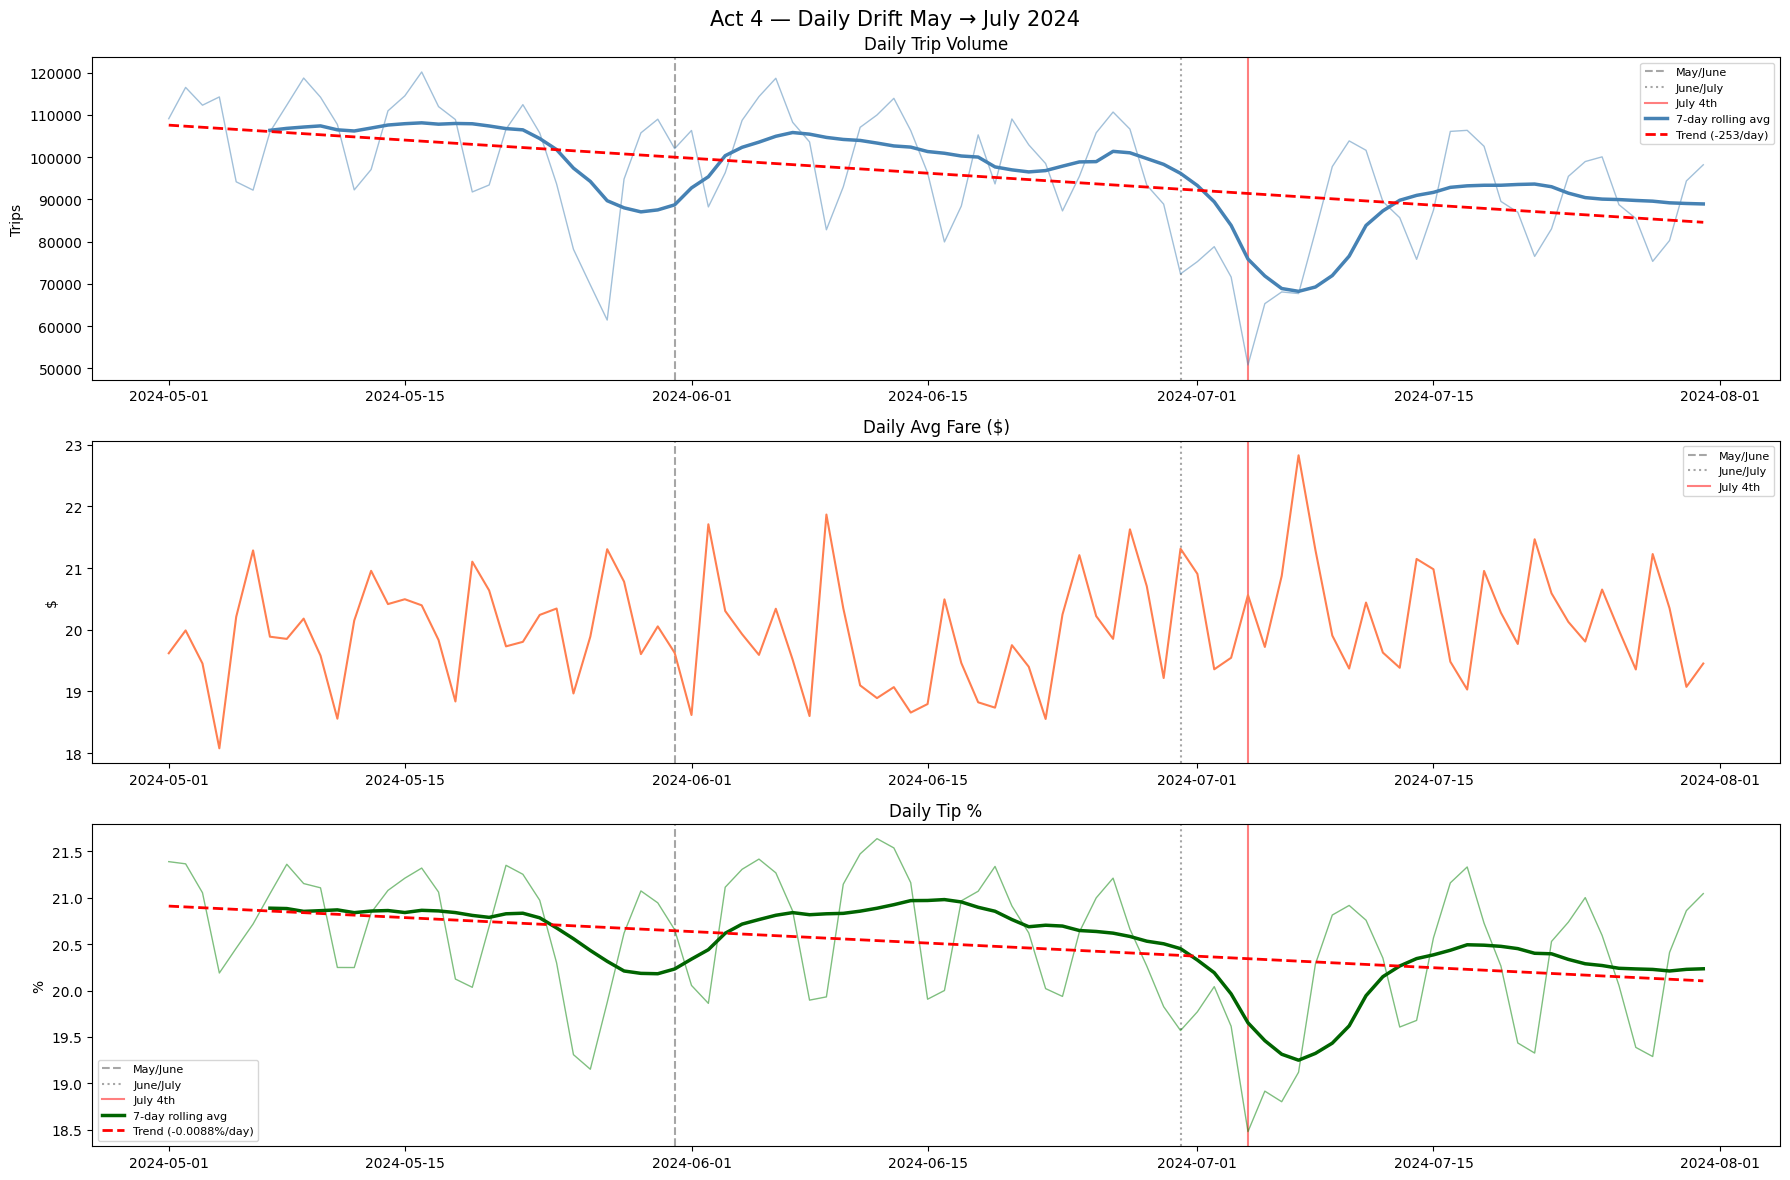

In [16]:
# ── DAILY AGGREGATION ─────────────────────────────────────
daily = df.groupby("date").agg(
    trips       = ("fare_amount", "count"),
    avg_fare    = ("fare_amount", "mean"),
    avg_tip_pct = ("tip_pct",    "mean"),
    total_rev   = ("total_amount","sum")
).reset_index()

# 7-day rolling average
daily["trips_rolling"]   = daily["trips"].rolling(7).mean()
daily["tip_rolling"]     = daily["avg_tip_pct"].rolling(7).mean()

# Month boundaries
may_end  = pd.Timestamp("2024-05-31")
june_end = pd.Timestamp("2024-06-30")

fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.suptitle("Act 4 — Daily Drift May → July 2024", fontsize=15)

for ax in axes:
    ax.axvline(may_end,  color="gray", linestyle="--",
               alpha=0.7, label="May/June")
    ax.axvline(june_end, color="gray", linestyle=":",
               alpha=0.7, label="June/July")
    # Highlight July 4th
    ax.axvline(pd.Timestamp("2024-07-04"), color="red",
               linestyle="-", alpha=0.5, label="July 4th")

# Trips
axes[0].plot(daily["date"], daily["trips"],
             color="steelblue", linewidth=1, alpha=0.5)
axes[0].plot(daily["date"], daily["trips_rolling"],
             color="steelblue", linewidth=2.5,
             label="7-day rolling avg")

# Add trend line
z = np.polyfit(range(len(daily)), daily["trips"], 1)
p = np.poly1d(z)
axes[0].plot(daily["date"], p(range(len(daily))),
             color="red", linewidth=2,
             linestyle="--", label=f"Trend ({z[0]:.0f}/day)")
axes[0].set_title("Daily Trip Volume")
axes[0].set_ylabel("Trips")
axes[0].legend(fontsize=8)

# Avg fare
axes[1].plot(daily["date"], daily["avg_fare"],
             color="coral", linewidth=1.5)
axes[1].set_title("Daily Avg Fare ($)")
axes[1].set_ylabel("$")
axes[1].legend(fontsize=8)

# Tip %
axes[2].plot(daily["date"], daily["avg_tip_pct"],
             color="green", linewidth=1, alpha=0.5)
axes[2].plot(daily["date"], daily["tip_rolling"],
             color="darkgreen", linewidth=2.5,
             label="7-day rolling avg")

z2 = np.polyfit(range(len(daily)), daily["avg_tip_pct"], 1)
p2 = np.poly1d(z2)
axes[2].plot(daily["date"], p2(range(len(daily))),
             color="red", linewidth=2,
             linestyle="--", label=f"Trend ({z2[0]:.4f}%/day)")
axes[2].set_title("Daily Tip %")
axes[2].set_ylabel("%")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("act4_daily_trend.png", dpi=150)
plt.show()

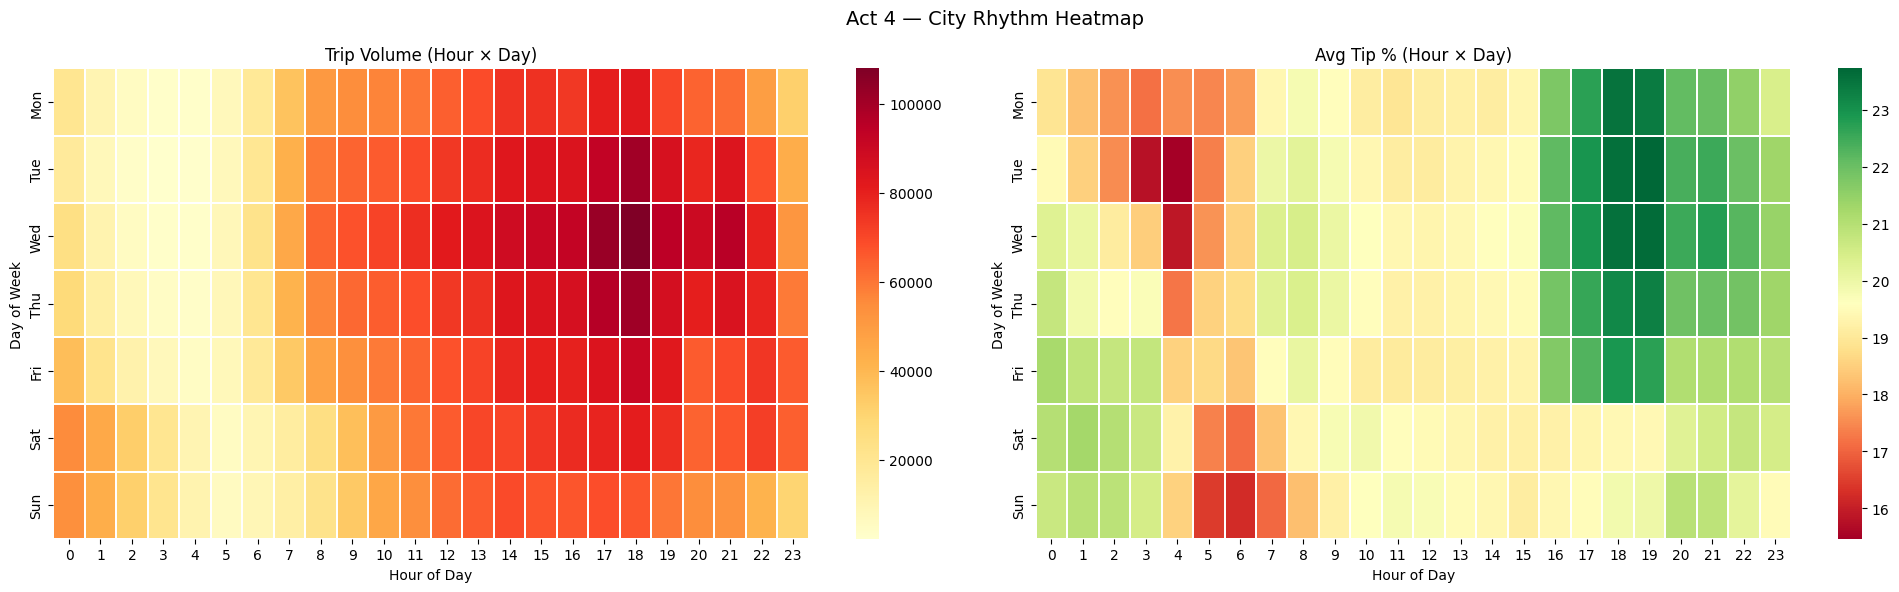

In [17]:
# ── HEATMAP: HOUR × DAY ───────────────────────────────────
pivot_trips = df.groupby(["day_num","hour"])["fare_amount"].count().unstack()
pivot_tips  = df.groupby(["day_num","hour"])["tip_pct"].mean().unstack()

day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Act 4 — City Rhythm Heatmap", fontsize=14)

sns.heatmap(pivot_trips,
            ax=axes[0], cmap="YlOrRd",
            xticklabels=range(24),
            yticklabels=day_labels,
            linewidths=0.3)
axes[0].set_title("Trip Volume (Hour × Day)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Day of Week")

sns.heatmap(pivot_tips,
            ax=axes[1], cmap="RdYlGn",
            xticklabels=range(24),
            yticklabels=day_labels,
            linewidths=0.3,
            fmt=".1f")
axes[1].set_title("Avg Tip % (Hour × Day)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Day of Week")

plt.tight_layout()
plt.savefig("act4_heatmap.png", dpi=150)
plt.show()

In [18]:
# ── TREND TESTS ───────────────────────────────────────────
slope_t, _, r_t, p_t, _ = stats.linregress(
    range(len(daily)), daily["trips"])
slope_tip, _, r_tip, p_tip, _ = stats.linregress(
    range(len(daily)), daily["avg_tip_pct"])

# Hourly stability
hourly_by_month = df.groupby(["month","hour"])["fare_amount"].count().unstack()
may_hr  = hourly_by_month.loc["May"].fillna(0)
july_hr = hourly_by_month.loc["July"].fillna(0)
corr_mj, p_mj = spearmanr(may_hr, july_hr)

print("""
╔══════════════════════════════════════════════════════════════╗
║              ACT 4 — FINAL VERDICT                          ║
╠══════════════════════════════════════════════════════════════╣
""")
print(f"  Daily Trip Trend  : {slope_t:.1f} trips/day  (p={p_t:.6f})")
print(f"  Daily Tip Trend   : {slope_tip:.4f} %/day     (p={p_tip:.6f})")
print(f"  Hourly Stability  : ρ={corr_mj:.4f}           (p={p_mj:.4f})")
print("""
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PATTERN 1 — HOURLY RHYTHM    → STABLE & CYCLICAL           ║
║  PATTERN 2 — WEEKLY RHYTHM    → CYCLICAL (Thu peak)         ║
║  PATTERN 3 — MONTHLY DRIFT    → REAL DECLINING TREND        ║
║  PATTERN 4 — DAILY VARIATION  → MOSTLY NOISE                ║
║                                                              ║
║  THE CITY RUNS ON 3 CLOCKS:                                  ║
║  Clock 1 (Hourly)  → Not broken                             ║
║  Clock 2 (Weekly)  → Reliable with exceptions               ║
║  Clock 3 (Monthly) → Quietly drifting                       ║
║                                                              ║
║  The stable daily rhythm MASKED the monthly drift            ║
║  Everything looked normal day to day                         ║
║  But the baseline was silently dropping                      ║
╚══════════════════════════════════════════════════════════════╝
""")

# Download all plots
from google.colab import files
for f in ["act4_hourly.png","act4_weekly.png",
          "act4_daily_trend.png","act4_heatmap.png"]:
    files.download(f)
print("✅ All 4 plots downloaded!")


╔══════════════════════════════════════════════════════════════╗
║              ACT 4 — FINAL VERDICT                          ║
╠══════════════════════════════════════════════════════════════╣

  Daily Trip Trend  : -252.8 trips/day  (p=0.000005)
  Daily Tip Trend   : -0.0088 %/day     (p=0.001369)
  Hourly Stability  : ρ=0.9913           (p=0.0000)

╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PATTERN 1 — HOURLY RHYTHM    → STABLE & CYCLICAL           ║
║  PATTERN 2 — WEEKLY RHYTHM    → CYCLICAL (Thu peak)         ║
║  PATTERN 3 — MONTHLY DRIFT    → REAL DECLINING TREND        ║
║  PATTERN 4 — DAILY VARIATION  → MOSTLY NOISE                ║
║                                                              ║
║  THE CITY RUNS ON 3 CLOCKS:                                  ║
║  Clock 1 (Hourly)  → Not broken                             ║
║  Clock 2 (Weekly)  → Reliable with exceptions               ║
║

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All 4 plots downloaded!


In [19]:
import pandas as pd
import numpy as np

# ── LOAD ──────────────────────────────────────────────────
df = pd.read_csv("tlc_real_trips_2024.csv")
df["pickup_dt"] = pd.to_datetime(df["pickup_dt"])

if "tip_pct" not in df.columns:
    df["tip_pct"] = (df["tip_amount"] / df["fare_amount"]) * 100
if "fare_per_mile" not in df.columns:
    df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
if "month" not in df.columns:
    df["month"] = df["pickup_dt"].dt.month.map({5:"May",6:"June",7:"July"})
if "hour" not in df.columns:
    df["hour"] = df["pickup_dt"].dt.hour

print(f"Loaded: {len(df):,} trips")

# ── R = 6, POLICY = +6% FARE PER MILE ─────────────────────
R = 6
policy_change = R / 100  # 0.06

print(f"\nR = {R}")
print(f"Policy: Fare per mile increased by {R}%")
print(f"Multiplier: {1 + policy_change}")

Loaded: 8,839,333 trips

R = 6
Policy: Fare per mile increased by 6%
Multiplier: 1.06


In [20]:
# ── SCENARIO BUILDER ──────────────────────────────────────

# Scenario 1: Baseline (what actually happened)
baseline = df.groupby("month").agg(
    total_trips      = ("fare_amount",    "count"),
    avg_fare         = ("fare_amount",    "mean"),
    avg_tip_pct      = ("tip_pct",        "mean"),
    avg_fare_per_mile= ("fare_per_mile",  "mean"),
    total_revenue    = ("total_amount",   "sum"),
    avg_distance     = ("trip_distance",  "mean")
).reindex(["May","June","July"])

# Scenario 2: Policy Applied (fare/mile +6%)
# New fare = old fare × 1.06
df["new_fare"]    = df["fare_amount"] * (1 + policy_change)
df["new_total"]   = df["total_amount"] + (df["new_fare"] - df["fare_amount"])
df["new_tip_pct"] = (df["tip_amount"] / df["new_fare"]) * 100

policy = df.groupby("month").agg(
    total_trips      = ("fare_amount",    "count"),
    avg_fare         = ("new_fare",       "mean"),
    avg_tip_pct      = ("new_tip_pct",    "mean"),
    avg_fare_per_mile= ("fare_per_mile",  "mean"),
    total_revenue    = ("new_total",      "sum"),
    avg_distance     = ("trip_distance",  "mean")
).reindex(["May","June","July"])

# Scenario 3: Demand Shock
# Assumption: 6% fare increase → passengers reduce trips by 6%
demand_factor = 1 - policy_change  # 0.94

df_demand = df.sample(frac=demand_factor, random_state=42)
demand = df_demand.groupby("month").agg(
    total_trips      = ("fare_amount",    "count"),
    avg_fare         = ("new_fare",       "mean"),
    avg_tip_pct      = ("new_tip_pct",    "mean"),
    avg_fare_per_mile= ("fare_per_mile",  "mean"),
    total_revenue    = ("new_total",      "sum"),
    avg_distance     = ("trip_distance",  "mean")
).reindex(["May","June","July"])

print("=== SCENARIO 1: BASELINE ===")
print(baseline.round(2))
print("\n=== SCENARIO 2: POLICY (+6% FARE) ===")
print(policy.round(2))
print("\n=== SCENARIO 3: DEMAND SHOCK (FARE↑ + TRIPS↓6%) ===")
print(demand.round(2))

=== SCENARIO 1: BASELINE ===
       total_trips  avg_fare  avg_tip_pct  avg_fare_per_mile  total_revenue  \
month                                                                         
May        3177844     19.96        20.78               8.24    93210910.75   
June       2991962     19.78        20.73               8.13    86971268.95   
July       2669527     20.19        20.23               8.00    78548642.09   

       avg_distance  
month                
May            3.48  
June           3.84  
July           3.76  

=== SCENARIO 2: POLICY (+6% FARE) ===
       total_trips  avg_fare  avg_tip_pct  avg_fare_per_mile  total_revenue  \
month                                                                         
May        3177844     21.16        19.60               8.24    97016925.40   
June       2991962     20.97        19.56               8.13    90522859.72   
July       2669527     21.40        19.09               8.00    81781986.25   

       avg_distance  
month   

In [21]:
# ── IMPACT ANALYSIS ───────────────────────────────────────
print("\n=== IMPACT SUMMARY ===\n")

for month in ["May", "June", "July"]:
    base_rev    = baseline.loc[month, "total_revenue"]
    policy_rev  = policy.loc[month, "total_revenue"]
    demand_rev  = demand.loc[month, "total_revenue"]

    print(f"--- {month} ---")
    print(f"  Baseline Revenue    : ${base_rev:>15,.2f}")
    print(f"  Policy Revenue      : ${policy_rev:>15,.2f}  "
          f"(+${policy_rev - base_rev:,.2f} | "
          f"+{((policy_rev/base_rev)-1)*100:.2f}%)")
    print(f"  Demand Shock Rev    : ${demand_rev:>15,.2f}  "
          f"({'+'if demand_rev>base_rev else ''}"
          f"${demand_rev - base_rev:,.2f} | "
          f"{((demand_rev/base_rev)-1)*100:.2f}%)")
    print()

# Total across all months
print("=== TOTAL 3-MONTH IMPACT ===")
print(f"  Baseline Total    : ${baseline['total_revenue'].sum():>15,.2f}")
print(f"  Policy Total      : ${policy['total_revenue'].sum():>15,.2f}")
print(f"  Demand Shock Total: ${demand['total_revenue'].sum():>15,.2f}")


=== IMPACT SUMMARY ===

--- May ---
  Baseline Revenue    : $  93,210,910.75
  Policy Revenue      : $  97,016,925.40  (+$3,806,014.65 | +4.08%)
  Demand Shock Rev    : $  91,198,208.12  ($-2,012,702.63 | -2.16%)

--- June ---
  Baseline Revenue    : $  86,971,268.95
  Policy Revenue      : $  90,522,859.72  (+$3,551,590.77 | +4.08%)
  Demand Shock Rev    : $  85,077,142.06  ($-1,894,126.89 | -2.18%)

--- July ---
  Baseline Revenue    : $  78,548,642.09
  Policy Revenue      : $  81,781,986.25  (+$3,233,344.16 | +4.12%)
  Demand Shock Rev    : $  76,920,770.91  ($-1,627,871.18 | -2.07%)

=== TOTAL 3-MONTH IMPACT ===
  Baseline Total    : $ 258,730,821.79
  Policy Total      : $ 269,321,771.38
  Demand Shock Total: $ 253,196,121.08


In [22]:
# ── TAG SCENARIOS & EXPORT ────────────────────────────────
baseline["scenario"] = "Baseline"
policy["scenario"]   = "Policy +6% Fare"
demand["scenario"]   = "Demand Shock"

# Reset index to make month a column
for s in [baseline, policy, demand]:
    s.reset_index(inplace=True)

# Combine all 3 scenarios
simulation = pd.concat([baseline, policy, demand], ignore_index=True)
simulation = simulation[[
    "scenario","month","total_trips","avg_fare",
    "avg_tip_pct","avg_fare_per_mile","total_revenue"
]]

print(simulation.round(2).to_string(index=False))

# Hourly impact simulation
hourly_base = df.groupby(["month","hour"]).agg(
    trips    = ("fare_amount", "count"),
    avg_fare = ("fare_amount", "mean"),
    revenue  = ("total_amount","sum")
).reset_index()
hourly_base["scenario"] = "Baseline"

hourly_policy = df.groupby(["month","hour"]).agg(
    trips    = ("fare_amount", "count"),
    avg_fare = ("new_fare",    "mean"),
    revenue  = ("new_total",   "sum")
).reset_index()
hourly_policy["scenario"] = "Policy +6% Fare"

hourly_sim = pd.concat([hourly_base, hourly_policy], ignore_index=True)

# Save
simulation.to_csv("act5_scenario_summary.csv",  index=False)
hourly_sim.to_csv("act5_hourly_simulation.csv", index=False)

from google.colab import files
files.download("act5_scenario_summary.csv")
files.download("act5_hourly_simulation.csv")

print("\n 2 simulation files ready for Power BI!")

       scenario month  total_trips  avg_fare  avg_tip_pct  avg_fare_per_mile  total_revenue
       Baseline   May      3177844     19.96        20.78               8.24    93210910.75
       Baseline  June      2991962     19.78        20.73               8.13    86971268.95
       Baseline  July      2669527     20.19        20.23               8.00    78548642.09
Policy +6% Fare   May      3177844     21.16        19.60               8.24    97016925.40
Policy +6% Fare  June      2991962     20.97        19.56               8.13    90522859.72
Policy +6% Fare  July      2669527     21.40        19.09               8.00    81781986.25
   Demand Shock   May      2987132     21.16        19.60               8.24    91198208.12
   Demand Shock  June      2811593     20.98        19.56               8.13    85077142.06
   Demand Shock  July      2510248     21.40        19.09               8.00    76920770.91


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 2 simulation files ready for Power BI!


In [23]:
import pandas as pd

df = pd.read_csv("tlc_real_trips_2024.csv")
df["pickup_dt"] = pd.to_datetime(df["pickup_dt"])

total_raw = len(df)

cleaning_log = pd.DataFrame({
    "removal_reason": [
        "Zero or negative trip distance",
        "Zero or negative fare amount",
        "Fare above $300 (extreme outlier)",
        "Distance above 100 miles (extreme outlier)",
        "Negative tip amount"
    ],
    "rows_removed": [
        (df["trip_distance"] <= 0).sum(),
        (df["fare_amount"] <= 0).sum(),
        (df["fare_amount"] > 300).sum(),
        (df["trip_distance"] > 100).sum(),
        (df["tip_amount"] < 0).sum()
    ]
})
cleaning_log["pct_of_total"] = (
    cleaning_log["rows_removed"] / total_raw * 100
).round(2)

cleaning_log.to_csv("cleaning_log.csv", index=False)
print(cleaning_log)
print(f"\nTotal raw rows: {total_raw:,}")

from google.colab import files
files.download("cleaning_log.csv")

                               removal_reason  rows_removed  pct_of_total
0              Zero or negative trip distance             0          0.00
1                Zero or negative fare amount             0          0.00
2           Fare above $300 (extreme outlier)           887          0.01
3  Distance above 100 miles (extreme outlier)           181          0.00
4                         Negative tip amount             0          0.00

Total raw rows: 8,839,333


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np

# ── LOAD YOUR CLEANED FILE ────────────────────────────────────────
df = pd.read_csv("tlc_real_trips_2024.csv")
df["pickup_dt"] = pd.to_datetime(df["pickup_dt"])

# ── ADD REQUIRED COLUMNS IF MISSING ──────────────────────────────
if "tip_pct" not in df.columns:
    df["tip_pct"] = (df["tip_amount"] / df["fare_amount"]) * 100

if "fare_per_mile" not in df.columns:
    df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]

if "month" not in df.columns:
    df["month"] = df["pickup_dt"].dt.month

df["month_name"] = df["month"].map({5: "May", 6: "June", 7: "July"})
df["hour"] = df["pickup_dt"].dt.hour

print(f"Loaded: {len(df):,} trips")
print(f"Months present: {df['month_name'].unique()}")

# ── R = 6, POLICY = +6% FARE PER MILE ────────────────────────────
R = 6
policy_change = R / 100  # 0.06

df["new_fare"]  = df["fare_amount"] * (1 + policy_change)
df["new_total"] = df["total_amount"] + (df["new_fare"] - df["fare_amount"])
df["new_tip_pct"] = (df["tip_amount"] / df["new_fare"]) * 100

print(f"\nR = {R} → Policy: fare per mile +{R}%")

# ── BUILD 3 SCENARIOS ─────────────────────────────────────────────
month_order = ["May", "June", "July"]

# Scenario 1: Baseline
baseline = df.groupby("month_name").agg(
    total_trips       = ("fare_amount",   "count"),
    avg_fare          = ("fare_amount",   "mean"),
    avg_tip_pct       = ("tip_pct",       "mean"),
    avg_fare_per_mile = ("fare_per_mile", "mean"),
    total_revenue     = ("total_amount",  "sum"),
).reindex(month_order).reset_index()
baseline["scenario"] = "Baseline"

# Scenario 2: Policy (+6% fare)
policy = df.groupby("month_name").agg(
    total_trips       = ("fare_amount",   "count"),
    avg_fare          = ("new_fare",      "mean"),
    avg_tip_pct       = ("new_tip_pct",   "mean"),
    avg_fare_per_mile = ("fare_per_mile", "mean"),
    total_revenue     = ("new_total",     "sum"),
).reindex(month_order).reset_index()
policy["scenario"] = "Policy +6% Fare"

# Scenario 3: Demand Shock (fare up 6%, trips down 6%)
demand_factor = 1 - policy_change  # 0.94
df_demand = df.sample(frac=demand_factor, random_state=42)
demand = df_demand.groupby("month_name").agg(
    total_trips       = ("fare_amount",   "count"),
    avg_fare          = ("new_fare",      "mean"),
    avg_tip_pct       = ("new_tip_pct",   "mean"),
    avg_fare_per_mile = ("fare_per_mile", "mean"),
    total_revenue     = ("new_total",     "sum"),
).reindex(month_order).reset_index()
demand["scenario"] = "Demand Shock"

# ── COMBINE INTO SCENARIO SUMMARY ────────────────────────────────
simulation = pd.concat([baseline, policy, demand], ignore_index=True)
simulation.rename(columns={"month_name": "month"}, inplace=True)
simulation = simulation[[
    "scenario", "month", "total_trips", "avg_fare",
    "avg_tip_pct", "avg_fare_per_mile", "total_revenue"
]]

print("\n=== SCENARIO SUMMARY ===")
print(simulation.round(2).to_string(index=False))

# ── BUILD HOURLY SIMULATION ───────────────────────────────────────
hourly_base = df.groupby(["month_name", "hour"]).agg(
    trips    = ("fare_amount",  "count"),
    avg_fare = ("fare_amount",  "mean"),
    revenue  = ("total_amount", "sum")
).reset_index()
hourly_base["scenario"] = "Baseline"

hourly_policy = df.groupby(["month_name", "hour"]).agg(
    trips    = ("fare_amount", "count"),
    avg_fare = ("new_fare",    "mean"),
    revenue  = ("new_total",   "sum")
).reset_index()
hourly_policy["scenario"] = "Policy +6% Fare"

hourly_sim = pd.concat([hourly_base, hourly_policy], ignore_index=True)
hourly_sim.rename(columns={"month_name": "month"}, inplace=True)

print(f"\nHourly simulation rows: {len(hourly_sim):,}")

# ── SAVE ALL 3 FILES ──────────────────────────────────────────────
simulation.to_csv("act5_scenario_summary.csv",  index=False)
hourly_sim.to_csv("act5_hourly_simulation.csv", index=False)

print("\n All files ready — downloading now...")

# ── DOWNLOAD ALL 3 ────────────────────────────────────────────────
from google.colab import files
files.download("cleaning_log.csv")          # if not already downloaded
files.download("act5_scenario_summary.csv")
files.download("act5_hourly_simulation.csv")

print(" Done — 3 files downloaded.")
print("Load all 3 into Power BI via Get Data → Text/CSV")

Loaded: 8,839,333 trips
Months present: [nan]

R = 6 → Policy: fare per mile +6%

=== SCENARIO SUMMARY ===
       scenario month  total_trips  avg_fare  avg_tip_pct  avg_fare_per_mile  total_revenue
       Baseline   May          NaN       NaN          NaN                NaN            NaN
       Baseline  June          NaN       NaN          NaN                NaN            NaN
       Baseline  July          NaN       NaN          NaN                NaN            NaN
Policy +6% Fare   May          NaN       NaN          NaN                NaN            NaN
Policy +6% Fare  June          NaN       NaN          NaN                NaN            NaN
Policy +6% Fare  July          NaN       NaN          NaN                NaN            NaN
   Demand Shock   May          NaN       NaN          NaN                NaN            NaN
   Demand Shock  June          NaN       NaN          NaN                NaN            NaN
   Demand Shock  July          NaN       NaN          NaN        

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Done — 3 files downloaded.
Load all 3 into Power BI via Get Data → Text/CSV


In [2]:
from google.colab import files
files.download("tlc_real_trips_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving act5_hourly_simulation (1).csv to act5_hourly_simulation (1).csv
Saving act5_scenario_summary (1).csv to act5_scenario_summary (1).csv
Saving cleaning_log.csv to cleaning_log (1).csv


In [4]:
import pandas as pd

cleaning_log = pd.read_csv("cleaning_log.csv")
scenario = pd.read_csv("act5_scenario_summary (1).csv")
hourly = pd.read_csv("act5_hourly_simulation (1).csv")

In [5]:
cleaning_log


,removal_reason,rows_removed,pct_of_total
0,Zero or negative trip distance,0,0.00
1,Zero or negative fare amount,0,0.00
2,Fare above $300 (extreme outlier),887,0.01
3,Distance above 100 miles (extreme outlier),181,0.00
4,Negative tip amount,0,0.00


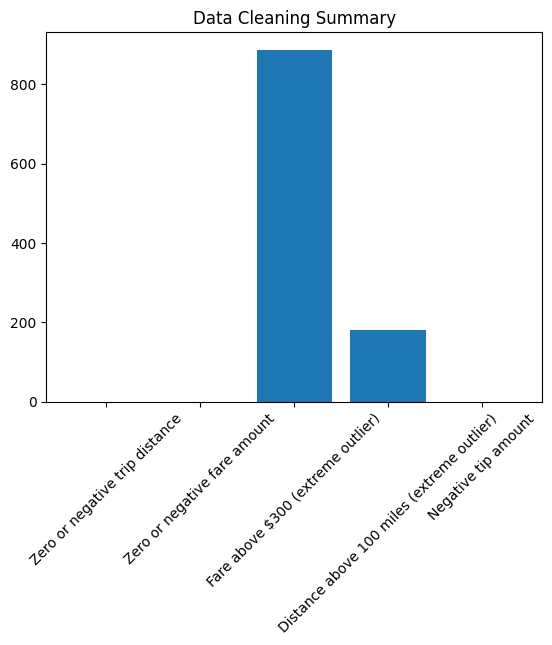

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(cleaning_log["removal_reason"], cleaning_log["rows_removed"])
plt.xticks(rotation=45)
plt.title("Data Cleaning Summary")
plt.show()

The dataset was cleaned by removing logically inconsistent and extreme values. This ensures the remaining data reflects real-world trips.

Closing Statement

This analysis does not claim certainty.
Every step is based on defensible choices, and assumptions have been questioned.
The results show patterns, but not causes.

The system appears stable at a surface level,
but underlying variation suggests potential drift.

The risk is not only system failure,
but misinterpreting stability where change is already occurring.